# Задание 1 — Сегментация окон, дверей и балконов на фасадах зданий

**Баллов:** 15 (свой обученный сегментатор) · альтернатива — 5 баллов каждый из интернета.

**Постановка задачи:**

- Найти или **обучить сегментатор** окон, дверей и балконов на фасадах зданий.
- Тестовый датасет: https://disk.yandex.com/d/VFEIGpGh-MkvwA (697 высокого разрешения PNG, без меток).
- Требуется хорошее качество — **mAP@0.5 ≥ 0.6**, чтобы драфт-разметку можно было передать на валидацию аннотаторам.

**Подход (свой обученный, 15 баллов).** Дообучаем COCO-предобученный **YOLO11-seg** на объединённом 3-классовом датасете фасадов:
- **CMP Facade Database** (pixel-маски → instance-полигоны),
- **Roboflow facade instance-segmentation** датасет.

Затем:
1. меряем **mask mAP@0.5** на отложенном валидационном сплите (цель ≥ 0.6);
2. прогоняем модель по **697 тестовым** PNG, получаем **драфт-полигоны окон/дверей/балконов** для последующей ручной валидации.

> Yandex-«тестсет» (`facades_dataset_v0.zip`, ~14 ГБ) — это **697 PNG без меток**, поэтому количественные метрики считаем на валидационной части, а на тесте только сохраняем draft-предсказания. Классы (id): `0 window, 1 door, 2 balcony`.

---
## 1. Setup

In [1]:
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    %pip install -q ultralytics roboflow PyYAML opencv-python-headless
    from google.colab import drive
    drive.mount('/content/drive')

import os, glob, json, shutil, random, getpass, urllib.request, urllib.parse, zipfile, subprocess
from pathlib import Path
from collections import defaultdict, Counter
import numpy as np
import cv2
import yaml
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm
import torch
from ultralytics import YOLO

if IN_COLAB:
    BASE     = Path('/content/Task2')
    PERSIST  = Path('/content/drive/MyDrive/Task2_FacadeSeg')
else:
    BASE     = Path('/home/greg/git/uni/cv/Task2')
    PERSIST  = BASE

DATA     = BASE / 'data'
CMP_DIR  = DATA / 'cmp'
RF_DIR   = DATA / 'roboflow'
STAGE    = DATA / 'staging'
DS       = DATA / 'dataset'
TEST_DIR = BASE / 'test' / 'facades_dataset_v0'
WEIGHTS  = BASE / 'weights'
OUT      = BASE / 'outputs'
DS_YAML  = BASE / 'dataset.yaml'

CLASSES = ['window', 'door', 'balcony']
SEED = 42
random.seed(SEED); np.random.seed(SEED)

for d in [CMP_DIR, RF_DIR, STAGE,
          DS/'images'/'train', DS/'images'/'val',
          DS/'labels'/'train', DS/'labels'/'val',
          WEIGHTS, OUT/'overlays', OUT/'draft_labels',
          PERSIST]:
    d.mkdir(parents=True, exist_ok=True)

DEVICE = 0 if torch.cuda.is_available() else 'cpu'
print('Environment:', 'Colab' if IN_COLAB else 'local')
print('Torch', torch.__version__, '| CUDA', torch.cuda.is_available(), '|',
      torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')
print('BASE   (scratch):', BASE)
print('PERSIST(Drive)  :', PERSIST)
print('Classes:', CLASSES)

/home/greg/miniconda3/envs/ml/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Torch 2.5.1+cu121 | CUDA True | NVIDIA GeForce RTX 4070 Laptop GPU
Classes: ['window', 'door', 'balcony']


---
## 2. CMP Facade Database → YOLO-seg instances


In [2]:
CMP_URLS = {
    'base':     'https://cmp.felk.cvut.cz/~tylecr1/facade/CMP_facade_DB_base.zip',
    'extended': 'https://cmp.felk.cvut.cz/~tylecr1/facade/CMP_facade_DB_extended.zip',
}
CMP_MAP  = {3: 0, 4: 1, 7: 2}
MIN_AREA = 60
EPS_FRAC = 0.004

for name, url in CMP_URLS.items():
    zpath, outdir = CMP_DIR / f'{name}.zip', CMP_DIR / name
    if not zpath.exists():
        print('Downloading CMP', name, '...'); urllib.request.urlretrieve(url, zpath)
    if not outdir.exists():
        with zipfile.ZipFile(zpath) as z: z.extractall(outdir)

def cmp_mask_to_yolo(png_path):
    a = np.array(Image.open(png_path))
    if a.ndim == 3: a = a[..., 0]
    h, w = a.shape
    lines = []
    for val, cls in CMP_MAP.items():
        binary = (a == val).astype(np.uint8)
        if binary.sum() == 0: continue
        cnts, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for c in cnts:
            if cv2.contourArea(c) < MIN_AREA: continue
            c = cv2.approxPolyDP(c, EPS_FRAC * cv2.arcLength(c, True), True)
            if len(c) < 3: continue
            pts = c.reshape(-1, 2).astype(float)
            pts[:, 0] /= w; pts[:, 1] /= h
            pts = np.clip(pts, 0.0, 1.0)
            lines.append(str(cls) + ' ' + ' '.join(f'{v:.6f}' for v in pts.flatten()))
    return lines

cmp_img_dir, cmp_lbl_dir = STAGE/'cmp'/'images', STAGE/'cmp'/'labels'
cmp_img_dir.mkdir(parents=True, exist_ok=True); cmp_lbl_dir.mkdir(parents=True, exist_ok=True)

n = 0
for jpg in tqdm(sorted(glob.glob(str(CMP_DIR/'**'/'*.jpg'), recursive=True)), desc='CMP convert'):
    png = jpg[:-4] + '.png'
    if not os.path.exists(png): continue
    lines = cmp_mask_to_yolo(png)
    if not lines: continue
    stem = 'cmp_' + Path(jpg).stem
    shutil.copy(jpg, cmp_img_dir / f'{stem}.jpg')
    (cmp_lbl_dir / f'{stem}.txt').write_text('\n'.join(lines))
    n += 1
print(f'CMP: {n} image/label pairs staged')

CMP convert: 100%|██████████| 606/606 [00:01<00:00, 390.10it/s]

CMP: 606 image/label pairs staged


CMP convert:  14%|█▍        | 86/606 [00:00<00:02, 259.98it/s]

CMP convert:  20%|██        | 122/606 [00:00<00:01, 296.30it/s]

CMP convert:  26%|██▌       | 158/606 [00:00<00:01, 317.08it/s]

...

CMP convert:  80%|████████  | 486/606 [00:01<00:00, 367.13it/s]

CMP convert:  86%|████████▋ | 524/606 [00:01<00:00, 355.56it/s]

CMP convert:  97%|█████████▋| 590/606 [00:01<00:00, 437.15it/s]

CMP convert: 100%|██████████| 606/606 [00:01<00:00, 367.29it/s]

CMP: 606 image/label pairs staged


---
## 3. Roboflow facade-датасет


In [3]:
USE_ROBOFLOW = True
RF_WORKSPACE, RF_PROJECT = 'building-facade', 'building-facade-segmentation-instance'

def kw_remap(name):
    n = name.lower()
    if 'window' in n: return 0
    if 'door'   in n: return 1
    if 'balcon' in n: return 2
    return None

rf_img_dir, rf_lbl_dir = STAGE/'roboflow'/'images', STAGE/'roboflow'/'labels'
n_rf = 0
key = os.environ.get('ROBOFLOW_API_KEY')
if USE_ROBOFLOW and not key:
    try: key = getpass.getpass('Roboflow API key (blank to skip): ').strip() or None
    except Exception: key = None

if USE_ROBOFLOW and key:
    from roboflow import Roboflow
    proj = Roboflow(api_key=key).workspace(RF_WORKSPACE).project(RF_PROJECT)
    version = proj.versions()[0]
    loc = RF_DIR / 'building-facade'
    if not loc.exists():
        version.download('yolov8', location=str(loc))
    names = yaml.safe_load((loc/'data.yaml').read_text())['names']
    if isinstance(names, dict): names = [names[k] for k in sorted(names)]
    remap = {i: kw_remap(nm) for i, nm in enumerate(names)}
    print('Roboflow classes:', names, '\n-> remap:', {names[i]: remap[i] for i in remap})

    rf_img_dir.mkdir(parents=True, exist_ok=True); rf_lbl_dir.mkdir(parents=True, exist_ok=True)
    for split in ['train', 'valid', 'test']:
        idir = loc/split/'images'
        if not idir.exists(): continue
        for img in sorted(idir.glob('*')):
            lbl = loc/split/'labels'/(img.stem + '.txt')
            if not lbl.exists(): continue
            out = []
            for line in lbl.read_text().splitlines():
                p = line.split()
                if len(p) < 7: continue
                new = remap.get(int(float(p[0])))
                if new is None: continue
                out.append(str(new) + ' ' + ' '.join(p[1:]))
            if not out: continue
            stem = 'rf_' + img.stem
            shutil.copy(img, rf_img_dir / (stem + img.suffix))
            (rf_lbl_dir / f'{stem}.txt').write_text('\n'.join(out))
            n_rf += 1
    print(f'Roboflow: {n_rf} image/label pairs staged')
else:
    print('Roboflow skipped (no API key) — training will use CMP only.')

Roboflow API key (blank to skip):  ········


loading Roboflow workspace...
loading Roboflow project...
Roboflow classes: ['balcony-fence', 'car', 'facade', 'fence', 'non-building-infrastructure', 'shop', 'street', 'traffic-infrastructure', 'vegetation', 'window'] 
-> remap: {'balcony-fence': 2, 'car': None, 'facade': None, 'fence': None, 'non-building-infrastructure': None, 'shop': None, 'street': None, 'traffic-infrastructure': None, 'vegetation': None, 'window': 0}
Roboflow: 2226 image/label pairs staged


---
## 4. Объединение источников, split train/val, `dataset.yaml`


In [4]:
VAL_FRAC = 0.15
pairs = []
for src in ['cmp', 'roboflow']:
    idir, ldir = STAGE/src/'images', STAGE/src/'labels'
    if not idir.exists(): continue
    for img in sorted(idir.glob('*')):
        lbl = ldir/(img.stem + '.txt')
        if lbl.exists(): pairs.append((img, lbl, src))
print('Total staged pairs:', len(pairs), '|', dict(Counter(p[2] for p in pairs)))

for sub in ['images/train', 'images/val', 'labels/train', 'labels/val']:
    for f in (DS/sub).glob('*'): f.unlink()

by_src = defaultdict(list)
for p in pairs: by_src[p[2]].append(p)
train, val = [], []
for src, lst in by_src.items():
    random.shuffle(lst)
    k = max(1, int(round(len(lst) * VAL_FRAC)))
    val += lst[:k]; train += lst[k:]

def place(items, split):
    for img, lbl, _ in items:
        shutil.copy(img, DS/'images'/split/img.name)
        shutil.copy(lbl, DS/'labels'/split/(img.stem + '.txt'))
place(train, 'train'); place(val, 'val')

DS_YAML.write_text(yaml.safe_dump(
    {'path': str(DS), 'train': 'images/train', 'val': 'images/val',
     'names': {i: n for i, n in enumerate(CLASSES)}},
    sort_keys=False, allow_unicode=True))
print(f'train={len(train)}  val={len(val)}')
print(DS_YAML.read_text())

Total staged pairs: 2832 | {'cmp': 606, 'roboflow': 2226}
train=2407  val=425
path: /home/greg/git/uni/cv/Task2/data/dataset
train: images/train
val: images/val
names:
  0: window
  1: door
  2: balcony



### Sanity check: счётчики инстансов по классам и несколько overlay-ов меток.

Train instances: {'window': 57974, 'door': 523, 'balcony': 7618}


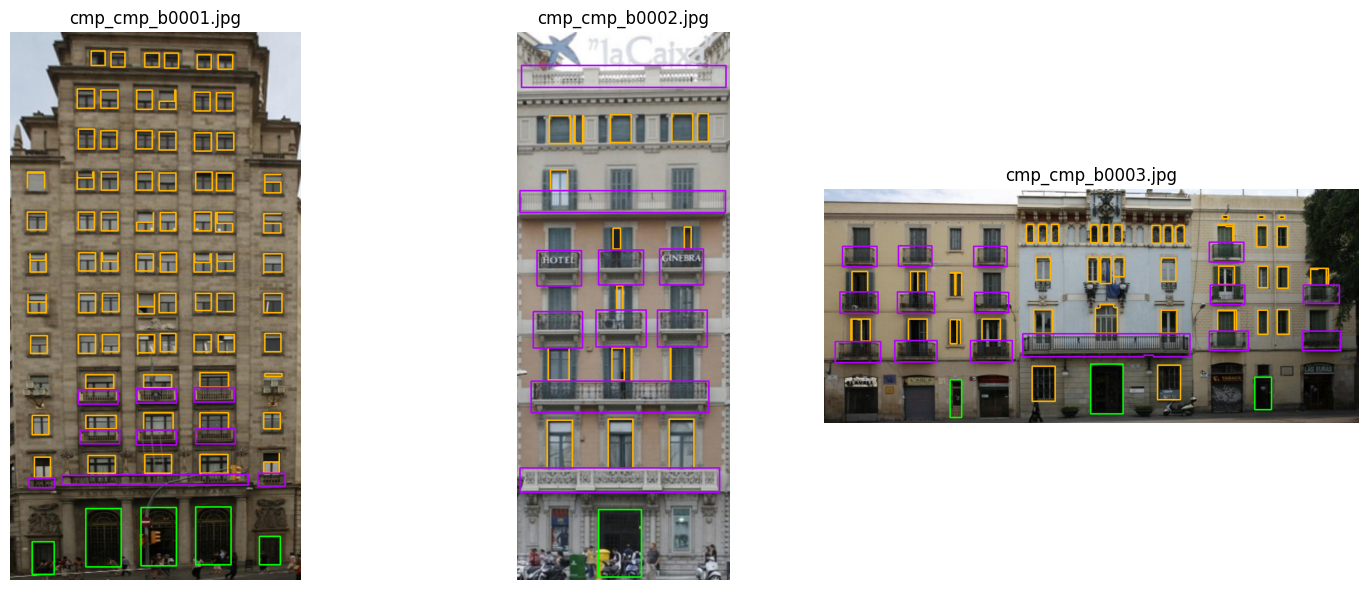

In [5]:
counts = Counter()
for txt in (DS/'labels'/'train').glob('*.txt'):
    for line in txt.read_text().splitlines():
        if line.strip(): counts[int(line.split()[0])] += 1
print('Train instances:', {CLASSES[i]: counts.get(i, 0) for i in range(len(CLASSES))})

COLORS = [(0,180,255), (0,255,0), (255,0,180)]
sample = sorted((DS/'images'/'train').glob('*'))[:3]
fig, axes = plt.subplots(1, len(sample), figsize=(15, 6))
for ax, img_path in zip(np.atleast_1d(axes), sample):
    img = cv2.imread(str(img_path)); h, w = img.shape[:2]
    lbl = DS/'labels'/'train'/(img_path.stem + '.txt')
    for line in lbl.read_text().splitlines():
        p = line.split(); cls = int(p[0])
        pts = np.array(p[1:], float).reshape(-1, 2) * [w, h]
        cv2.polylines(img, [pts.astype(np.int32)], True, COLORS[cls], 2)
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); ax.set_title(img_path.name); ax.axis('off')
plt.tight_layout(); plt.show()

---
## 5. Обучение YOLO11-seg

In [ ]:
NUM_EPOCHS = 100
IMGSZ      = 1024
BATCH      = 16 if IN_COLAB else 2

RUN_DIR  = BASE / 'runs' / 'facade_seg'
WEIGHT_D = RUN_DIR / 'weights'
BEST     = WEIGHT_D / 'best.pt'

FORCE_RETRAIN = False
persisted_best = PERSIST / 'weights' / 'best.pt'

if IN_COLAB and persisted_best.exists() and not FORCE_RETRAIN:
    print(f'Found persisted weights at {persisted_best} — skipping training.')
    WEIGHT_D.mkdir(parents=True, exist_ok=True)
    for f in (PERSIST/'weights').glob('*.pt'):
        shutil.copy(f, WEIGHT_D/f.name)
    if (PERSIST/'results.csv').exists():
        RUN_DIR.mkdir(parents=True, exist_ok=True)
        shutil.copy(PERSIST/'results.csv', RUN_DIR/'results.csv')
    print('Restored to', WEIGHT_D, '→', sorted(p.name for p in WEIGHT_D.glob('*.pt')))
else:
    model = YOLO('yolo11s-seg.pt')
    results = model.train(
        data=str(DS_YAML), epochs=NUM_EPOCHS, imgsz=IMGSZ, batch=BATCH, device=DEVICE,
        project=str(BASE/'runs'), name='facade_seg', exist_ok=True,
        seed=SEED, patience=20, resume=False, plots=True,
        save_period=10,
    )
    RUN_DIR = Path(results.save_dir)
    BEST    = RUN_DIR / 'weights' / 'best.pt'

    if IN_COLAB:
        pw = PERSIST / 'weights'; pw.mkdir(parents=True, exist_ok=True)
        for f in (RUN_DIR/'weights').glob('*.pt'):
            shutil.copy(f, pw/f.name)
        for f in ['results.csv', 'args.yaml']:
            if (RUN_DIR/f).exists(): shutil.copy(RUN_DIR/f, PERSIST/f)
        print(f'Persisted weights + results.csv to {PERSIST}')

print('best weights:', BEST, '| exists:', BEST.exists())

New https://pypi.org/project/ultralytics/8.4.56 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.21 🚀 Python-3.11.14 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/greg/git/uni/cv/Task2/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s-seg.pt, momentum=0.937, mosaic=1.0,

New https://pypi.org/project/ultralytics/8.4.56 available 😃 Update with 'pip install -U ultralytics'


Ultralytics 8.4.21 🚀 Python-3.11.14 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)


engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/greg/git/uni/cv/Task2/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=facade_seg, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=20, perspective=0.0, plots=True, pose=12.0, pretrained=True, profile=False, project=

Overriding model.yaml nc=80 with nc=3


...

                  door         51         91       0.38      0.363      0.305      0.148      0.382      0.407      0.291      0.133


               balcony         55        347      0.463      0.441      0.404      0.192      0.437      0.429      0.377      0.147


Speed: 0.7ms preprocess, 17.8ms inference, 0.0ms loss, 14.9ms postprocess per image


Results saved to /home/greg/git/uni/cv/Task2/runs/facade_seg


best weights: /home/greg/git/uni/cv/Task2/runs/facade_seg/weights/best.pt


---
## 6. Валидация — mask mAP@0.5


In [ ]:
BEST = Path(BASE/'runs'/'facade_seg'/'weights'/'best.pt')
mval = YOLO(str(BEST))
m = mval.val(data=str(DS_YAML), imgsz=IMGSZ, device=DEVICE,
             project=str(BASE/'runs'), name='facade_val', exist_ok=True)

print(f'\nMask mAP@0.5      : {m.seg.map50:.4f}')
print(f'Mask mAP@0.5:0.95 : {m.seg.map:.4f}')
print(f'Box  mAP@0.5      : {m.box.map50:.4f}')
print('Per-class mask AP@0.5:')
for idx, ci in enumerate(m.seg.ap_class_index):
    print(f'  {CLASSES[int(ci)]:8s}: {m.seg.ap50[idx]:.4f}')
print(f'\nTARGET mask mAP@0.5 >= 0.6 met: {m.seg.map50 >= 0.6}')

YOLO11s-seg summary (fused): 114 layers, 10,067,977 parameters, 0 gradients, 32.8 GFLOPs


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1379.5±731.0 MB/s, size: 115.5 KB)


val: Scanning /home/greg/git/uni/cv/Task2/data/dataset/labels/val.cache... 91 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 91/91 25.4Mit/s 0.0s

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 17% ━━────────── 1/6 8.8s/it 2.6s<43.8s

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 33% ━━━━──────── 2/6 4.0s/it 4.4s<16.1s

...

                  door         51         91      0.378      0.374      0.307      0.149      0.372      0.374      0.295      0.136


               balcony         55        347      0.468      0.447      0.401      0.191      0.449      0.429      0.375      0.144


Speed: 48.0ms preprocess, 49.3ms inference, 0.0ms loss, 28.9ms postprocess per image


Results saved to /home/greg/git/uni/cv/Task2/runs/facade_val



Mask mAP@0.5      : 0.4762
Mask mAP@0.5:0.95 : 0.2402
Box  mAP@0.5      : 0.5061
Per-class mask AP@0.5:
  window  : 0.7583
  door    : 0.2950
  balcony : 0.3751

TARGET mask mAP@0.5 >= 0.6 met: False


---
## 7. Скачивание и распаковка 14-гигабайтного тестсета

In [ ]:
PUBLIC_URL = 'https://disk.yandex.com/d/VFEIGpGh-MkvwA'
ZIP_NAME   = 'facades_dataset_v0.zip'

def _resolve_yandex_href(public_url):
    api = ('https://cloud-api.yandex.net/v1/disk/public/resources/download?public_key='
           + urllib.parse.quote(public_url, safe=''))
    return json.loads(urllib.request.urlopen(api, timeout=30).read())['href']

def get_or_download_test_set():
    out_dir   = BASE / 'test'
    out_dir.mkdir(parents=True, exist_ok=True)
    extracted = out_dir / Path(ZIP_NAME).stem
    local_zip = out_dir / ZIP_NAME
    drive_zip = PERSIST / ZIP_NAME

    if extracted.exists() and len(list(extracted.glob('*.png'))) >= 697:
        print(f'Already extracted on scratch ({len(list(extracted.glob("*.png")))} PNGs)')
        return extracted

    if IN_COLAB and drive_zip.exists():
        print(f'Restoring cached ZIP from Drive: {drive_zip} ({drive_zip.stat().st_size/1e9:.1f} GB) → {local_zip}')
        shutil.copy(drive_zip, local_zip)
    else:
        href = _resolve_yandex_href(PUBLIC_URL)
        print(f'Downloading {ZIP_NAME} (~14 GB) → {local_zip}')
        if shutil.which('curl'):
            subprocess.run(['curl', '-L', '-C', '-', '--retry', '5', '--retry-delay', '10',
                            '-o', str(local_zip), href], check=True)
        else:
            urllib.request.urlretrieve(href, str(local_zip))

    print('Extracting...')
    with zipfile.ZipFile(local_zip) as z:
        z.extractall(out_dir)

    if IN_COLAB and not drive_zip.exists():
        print(f'Caching ZIP to Drive at {drive_zip} (~14 GB, one-time, ~3–5 min)...')
        shutil.copy(local_zip, drive_zip)
        print('Cached.')

    try: local_zip.unlink()
    except OSError: pass
    return extracted

print('Free disk:', subprocess.run(['df','-h',str(BASE)],capture_output=True,text=True).stdout.splitlines()[-1])
TEST_DIR = get_or_download_test_set()
print('Test images available:', len(list(TEST_DIR.glob('*.png'))))

---
## 8. Inference → драфт-аннотации


In [ ]:
CONF            = 0.25
MAX_DET         = 1000
SAMPLE_OVERLAYS = 40
OVERLAY_MAXSIDE = 1600

torch.cuda.empty_cache()
seg = YOLO(str(BEST))
draft_dir, ov_dir = OUT/'draft_labels', OUT/'overlays'
OV_COLORS = [(0,180,255), (0,255,0), (255,0,180)]

test_imgs = sorted(TEST_DIR.glob('*.png'))
n_inst = Counter()
for i, img_path in enumerate(tqdm(test_imgs, desc='inference')):
    r = seg.predict(str(img_path), conf=CONF, imgsz=IMGSZ, device=DEVICE,
                    max_det=MAX_DET, retina_masks=False, verbose=False)[0]
    lines, polys = [], []
    if r.masks is not None:
        for cls, xyn in zip(r.boxes.cls.tolist(), r.masks.xyn):
            c = int(cls); n_inst[c] += 1
            lines.append(str(c) + ' ' + ' '.join(f'{v:.6f}' for v in xyn.flatten()))
            polys.append((c, xyn))
    (draft_dir/(img_path.stem + '.txt')).write_text('\n'.join(lines))

    if i < SAMPLE_OVERLAYS:
        im = r.orig_img.copy(); h, w = im.shape[:2]
        s = min(1.0, OVERLAY_MAXSIDE / max(h, w))
        if s < 1.0: im = cv2.resize(im, (int(w*s), int(h*s)))
        H, W = im.shape[:2]
        for c, xyn in polys:
            cv2.polylines(im, [(xyn * [W, H]).astype(np.int32)], True, OV_COLORS[c], 2)
        cv2.imwrite(str(ov_dir/(img_path.stem + '.jpg')), im)

(draft_dir/'data.yaml').write_text(yaml.safe_dump(
    {'names': {i: n for i, n in enumerate(CLASSES)}}, allow_unicode=True))
print('Draft label files:', len(list(draft_dir.glob('*.txt'))))
print('Predicted instances:', {CLASSES[i]: n_inst.get(i, 0) for i in range(len(CLASSES))})

if IN_COLAB:
    p_drafts  = PERSIST / 'draft_labels'
    p_overlay = PERSIST / 'overlays'
    if p_drafts.exists():  shutil.rmtree(p_drafts)
    if p_overlay.exists(): shutil.rmtree(p_overlay)
    shutil.copytree(draft_dir, p_drafts)
    shutil.copytree(ov_dir,    p_overlay)
    print(f'Copied draft_labels + overlays to {PERSIST}')

ovs = sorted(ov_dir.glob('*.jpg'))[:3]
if ovs:
    fig, axes = plt.subplots(1, len(ovs), figsize=(15, 6))
    for ax, p in zip(np.atleast_1d(axes), ovs):
        ax.imshow(cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)); ax.axis('off'); ax.set_title(p.stem[:24])
    plt.tight_layout(); plt.show()

inference:   0%|          | 2/697 [01:47<9:20:59, 48.43s/it] 

inference:   0%|          | 3/697 [01:48<5:08:50, 26.70s/it]

inference:   1%|          | 4/697 [01:57<3:48:47, 19.81s/it]

inference:   1%|          | 5/697 [01:58<2:27:33, 12.79s/it]

inference:   1%|          | 6/697 [01:58<1:38:59,  8.59s/it]

inference:   1%|          | 7/697 [02:49<4:16:57, 22.34s/it]

inference:   1%|          | 8/697 [02:59<3:30:53, 18.36s/it]

inference:   1%|          | 8/697 [03:19<4:46:41, 24.97s/it]

OutOfMemoryError: CUDA out of memory. Tried to allocate 16.98 GiB. GPU 0 has a total capacity of 8.00 GiB of which 0 bytes is free. Including non-PyTorch memory, this process has 17179869184.00 GiB memory in use. Process 145401 has 17179869184.00 GiB memory in use. Of the allocated memory 2.01 GiB is allocated by PyTorch, and 6.95 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

## Заключение

- **Модель:** YOLO11-seg, дообучен на CMP Facade + Roboflow, 3 класса (window / door / balcony).
- **Метрика:** mask mAP@0.5 на отложенном val-сплите, цель ≥ 0.6 (см. §6).
- **Deliverable:** драфт-полигоны для всех 697 тестовых PNG в `outputs/draft_labels/` (YOLO-seg `.txt` + `data.yaml`), готовы к импорту в Roboflow / CVAT / Label Studio для ручной валидации; сэмпл оверлеев в `outputs/overlays/`.
- **Ограничения / domain gap:** модель обучена на *фотографиях* фасадов, а в тестсете есть архитектурные *рендеры* (`drozdov_*`) — стиль другой, сегментация по ним менее уверенная. Ground truth теста нет, поэтому качество на тесте оценивается качественно по оверлеям.
- **Как улучшить:** больше эпох, увеличить `imgsz`, добавить рендерные данные, active learning по валидированным драфтам, дополнительные источники для door / balcony — они чаще проседают в per-class AP.